In [ ]:
# --- LANGKAH 1: PENGUMPULAN DATA (DATA COLLECTION) ---

import pandas as pd
import yfinance as yf

# --- KONFIGURASI ---
ticker = "ETH-USD"
start_date = "2024-01-01"
end_date = "2025-08-31"

# --- LOGIKA PENYESUAIAN TANGGAL ---
end_date_adjusted = (pd.to_datetime(end_date) + pd.Timedelta(days=1)).strftime("%Y-%m-%d")

print(f"Sedang mengunduh data dari {start_date} sampai {end_date} (System adjusted to: {end_date_adjusted})...")

# --- DOWNLOAD DATA ---
df = yf.download(ticker, start=start_date, end=end_date_adjusted)

# Reset index agar 'Date' menjadi kolom biasa (lebih rapi saat ditampilkan)
df = df.reset_index()

# --- TAMPILKAN HASIL ---
print(f"\n✅ Jumlah data yang berhasil diambil: {len(df)} baris")
print("📈 Data harga Ethereum:\n")

# Menampilkan 5 baris pertama & terakhir
try:
    display(df.head())
    display(df.tail())
except:
    print(df.head())
    print(df.tail())

/tmp/ipython-input-1727953062.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date_adjusted)
[*********************100%***********************]  1 of 1 completed

Sedang mengunduh data dari 2024-01-01 sampai 2025-08-31 (System adjusted to: 2025-09-01)...

✅ Jumlah data yang berhasil diambil: 609 baris
📈 Data harga Ethereum:



Price,Date,Close,High,Low,Open,Volume
Ticker,,ETH-USD,ETH-USD,ETH-USD,ETH-USD,ETH-USD
0,2024-01-01,2352.327881,2352.327881,2267.018066,2282.870361,6906765990
1,2024-01-02,2355.836426,2431.212402,2348.892334,2352.593506,12910543630
2,2024-01-03,2210.761963,2385.117676,2113.925293,2355.981445,19332933581
3,2024-01-04,2269.038086,2294.608154,2204.865723,2210.529053,11044564896
4,2024-01-05,2268.647217,2276.764648,2209.537109,2269.409424,10860953290


Price,Date,Close,High,Low,Open,Volume
Ticker,,ETH-USD,ETH-USD,ETH-USD,ETH-USD,ETH-USD
604,2025-08-27,4503.393066,4659.987305,4489.297852,4600.510254,43509902322
605,2025-08-28,4507.177734,4629.031250,4435.109375,4503.631348,36045274078
606,2025-08-29,4360.152832,4513.859375,4272.459473,4507.631348,46899991962
607,2025-08-30,4374.153320,4413.274902,4264.195312,4360.088867,25883112278
608,2025-08-31,4390.019043,4497.176758,4373.596680,4374.893555,26683044984


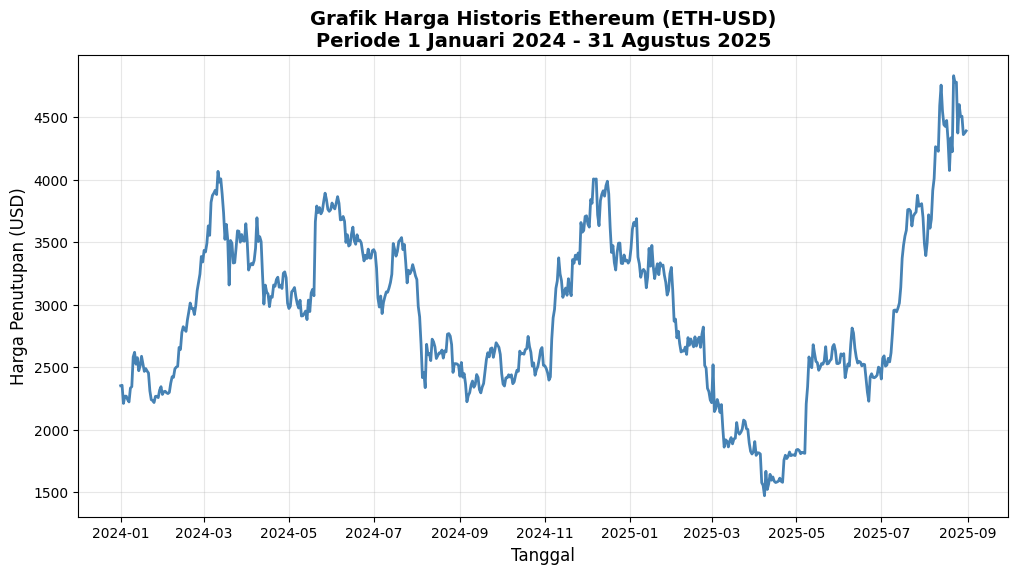

In [ ]:

import matplotlib.pyplot as plt

# Pastikan df sudah ada (dari langkah download data sebelumnya)
# Jika df belum reset index (Date masih jadi index), kita reset dulu agar kolom 'Date' muncul
if 'Date' not in df.columns:
    df = df.reset_index()

# --- Buat plot harga historis (Close) ---
plt.figure(figsize=(12,6))

# Plotting
plt.plot(df["Date"], df["Close"], color="steelblue", linewidth=2)

# Judul dan Label
plt.title("Grafik Harga Historis Ethereum (ETH-USD)\nPeriode 1 Januari 2024 - 31 Agustus 2025",
          fontsize=14, fontweight="bold")
plt.xlabel("Tanggal", fontsize=12)
plt.ylabel("Harga Penutupan (USD)", fontsize=12)

# Grid tipis agar mudah dibaca
plt.grid(alpha=0.3)

# Simpan gambar agar bisa dimasukkan ke Word nanti
plt.savefig('Gambar_4_1_Harga_Ethereum.png')

# Tampilkan
plt.show()

In [ ]:
# Menampilkan informasi umum tentang dataset
print("📋 Informasi Dataset:")
print(df.info())

📋 Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 609 entries, 0 to 608
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   (Date, )           609 non-null    datetime64[ns]
 1   (Close, ETH-USD)   609 non-null    float64       
 2   (High, ETH-USD)    609 non-null    float64       
 3   (Low, ETH-USD)     609 non-null    float64       
 4   (Open, ETH-USD)    609 non-null    float64       
 5   (Volume, ETH-USD)  609 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 28.7 KB
None


In [ ]:
# --- LANGKAH 2.1: CEK & TANGANI MISSING VALUE ---

print("🔍 MEMERIKSA MISSING VALUES...")

# 1. Cek jumlah null
missing_count = df[['Date', 'Close']].isnull().sum()
print(f"\nJumlah Data Kosong:\n{missing_count}")

# 2. Cek baris spesifik (jika ada)
missing_rows = df[df[['Date', 'Close']].isnull().any(axis=1)]

if len(missing_rows) > 0:
    print(f"\n⚠️ PERINGATAN: Ditemukan {len(missing_rows)} baris data kosong!")
    display(missing_rows)

    print("\n🛠️ Melakukan penanganan missing value (Interpolasi)...")
    df['Close'] = df['Close'].interpolate(method='linear')

    # Cek ulang
    print(f"Status setelah perbaikan: {df['Close'].isnull().sum()} missing value.")
else:
    print("\n✅ STATUS: Data Bersih. Tidak ditemukan missing value pada kolom Date dan Close.")

🔍 MEMERIKSA MISSING VALUES...

Jumlah Data Kosong:
Price  Ticker 
Date              0
Close  ETH-USD    0
dtype: int64

✅ STATUS: Data Bersih. Tidak ditemukan missing value pada kolom Date dan Close.


In [ ]:
# --- LANGKAH 2.2: NORMALISASI DATA (MINMAX SCALER) ---

from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np

# 1. Ambil kolom 'Close' saja
# Kita ubah ke bentuk array 2D karena MinMaxScaler membutuhkan input (n_samples, n_features)
data_close = df[['Close']].values

# 2. Inisialisasi Scaler (Range 0 sampai 1)
scaler = MinMaxScaler(feature_range=(0, 1))

# 3. Lakukan Normalisasi (Fit & Transform)
scaled_data = scaler.fit_transform(data_close)

# --- TAMPILKAN HASIL UNTUK VALIDASI ---
# Kita buat DataFrame sementara untuk melihat perbandingan Harga Asli vs Normalisasi
df_comparison = pd.DataFrame(data_close, columns=['Harga Asli (USD)'])
df_comparison['Harga Normalisasi'] = scaled_data

print("✅ Normalisasi Selesai.")
print(f"Nilai Min (X_min): {scaler.data_min_[0]}")
print(f"Nilai Max (X_max): {scaler.data_max_[0]}")
print("\n🔍 5 Data Pertama Setelah Normalisasi:")
display(df_comparison.head())

✅ Normalisasi Selesai.
Nilai Min (X_min): 1472.5531005859375
Nilai Max (X_max): 4831.3486328125

🔍 5 Data Pertama Setelah Normalisasi:


,Harga Asli (USD),Harga Normalisasi
0,2352.327881,0.261932
1,2355.836426,0.262976
2,2210.761963,0.219784
3,2269.038086,0.237134
4,2268.647217,0.237018


In [ ]:
import numpy as np

# --- LANGKAH 2.3: SLIDING WINDOW ---

# Mendefinisikan fungsi create_dataset
def create_dataset(data, time_step):
    X, y = [], []
    # Menggunakan logika loop (len(data) - time_step - 1)
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

# --- IMPLEMENTASI ---
# Mengatur time_step menjadi 30
time_step = 30

# Memanggil fungsi
X, y = create_dataset(scaled_data, time_step)

# --- [PENTING!] RESHAPE KE 3D (YANG HILANG TADI) ---
# Mengubah dimensi dari (Samples, 30) menjadi (Samples, 30, 1)
X = X.reshape(X.shape[0], X.shape[1], 1)

# --- CEK HASIL ---
print(f"✅ Sliding Window Selesai dengan Time Step: {time_step}")
print(f"Dimensi X (Input) : {X.shape}") # Sekarang harusnya (xxx, 30, 1)
print(f"Dimensi y (Target): {y.shape}")

✅ Sliding Window Selesai dengan Time Step: 30
Dimensi X (Input) : (578, 30, 1)
Dimensi y (Target): (578,)


In [ ]:
# --- CEK PEMBAGIAN DATA 80:20 ---

# Hitung jumlah sampel total setelah Sliding Window
total_samples = len(X)

# Hitung batas training (80%)
train_limit = int(total_samples * 0.8)

# Lakukan Splitting data
X_train, X_test = X[:train_limit], X[train_limit:]
y_train, y_test = y[:train_limit], y[train_limit:]

print("\n📊 VALIDASI PEMBAGIAN DATA (80:20)")
print("====================================")
print(f"1. Total Data Mentah (Baris Excel) : {len(scaled_data)}")
print(f"2. Dikurangi Time Step (30 hari)   : -30")
print(f"3. Total Sampel Siap Pakai (X)     : {total_samples}")
print("------------------------------------")
print(f"✅ Data Latih (X_train) - 80%      : {len(X_train)} sampel")
print(f"✅ Data Uji   (X_test)  - 20%      : {len(X_test)} sampel")
print("====================================")

# Cek Dimensi Akhir (Harus 3D untuk GRU)
print(f"Dimensi X_train Final: {X_train.shape}")
print(f"Dimensi X_test Final : {X_test.shape}")


📊 VALIDASI PEMBAGIAN DATA (80:20)
1. Total Data Mentah (Baris Excel) : 609
2. Dikurangi Time Step (30 hari)   : -30
3. Total Sampel Siap Pakai (X)     : 578
------------------------------------
✅ Data Latih (X_train) - 80%      : 462 sampel
✅ Data Uji   (X_test)  - 20%      : 116 sampel
Dimensi X_train Final: (462, 30, 1)
Dimensi X_test Final : (116, 30, 1)


In [ ]:
# --- CEK NILAI UNTUK PERHITUNGAN MANUAL ---
sample_real = X_train[0][-1][0]

print(f"\n✅ Nilai x_t asli dari dataset: {sample_real}")


✅ Nilai x_t asli dari dataset: 0.2595991757735246


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ================================
# 1. KONFIGURASI GRID SEARCH
# ================================
param_grid = {
    "GRU_unit":   [16, 32, 64, 128],
    "dropout":    [0.1, 0.2],
    "batch_size": [32],
    "epochs":     [50],
}

es = EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True, verbose=0
)

best_rmse = float('inf')
best_model = None
best_history = None
best_params = {}
best_y_pred = None

results = []

print(f"🚀 MEMULAI TRAINING (8 KOMBINASI)...\n")

# ================================
# 2. PROSES TRAINING (LOOPING)
# ================================
total_iter = len(param_grid['GRU_unit']) * len(param_grid['dropout'])
current_iter = 0

for units in param_grid["GRU_unit"]:
    for drop in param_grid["dropout"]:
        for batch in param_grid["batch_size"]:
            for epoch in param_grid["epochs"]:

                current_iter += 1
                print(f"🔄 [{current_iter}/{total_iter}] Training: Units={units}, Drop={drop}...", end=" ")

                # --- Bangun Model ---
                model = Sequential([
                    Input(shape=(X_train.shape[1], 1)),
                    GRU(units, activation='tanh', return_sequences=False),
                    Dropout(drop),
                    Dense(1, activation='linear')
                ])
                model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

                # --- Latih Model ---
                history = model.fit(
                    X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=epoch,
                    batch_size=batch,
                    callbacks=[es],
                    verbose=1
                )

                # --- Evaluasi ---
                y_pred = model.predict(X_test, verbose=0)

                mse = mean_squared_error(y_test, y_pred)
                rmse = np.sqrt(mse)
                mae = mean_absolute_error(y_test, y_pred)

                print(f"✅ RMSE: {rmse:.5f}")

                # --- Simpan ke Tabel (TANPA KOLOM SKENARIO) ---
                results.append({
                    'GRU Units': units,
                    'Dropout': drop,
                    'RMSE': rmse,
                    'MSE': mse,
                    'MAE': mae
                })

                # --- Cek Terbaik ---
                if rmse < best_rmse:
                    best_rmse = rmse
                    best_model = model
                    best_history = history
                    best_params = {'Unit': units, 'Drop': drop}
                    best_y_pred = y_pred

🚀 MEMULAI TRAINING (8 KOMBINASI)...

🔄 [1/8] Training: Units=16, Drop=0.1... Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.4583 - mae: 0.6148 - val_loss: 0.3786 - val_mae: 0.5325
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.2172 - mae: 0.4041 - val_loss: 0.1756 - val_mae: 0.3263
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0840 - mae: 0.2451 - val_loss: 0.0726 - val_mae: 0.1902
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0350 - mae: 0.1558 - val_loss: 0.0427 - val_mae: 0.1778
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0321 - mae: 0.1455 - val_loss: 0.0392 - val_mae: 0.1698
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0284 - mae: 0.1367 - val_loss: 0.0394 - val_mae: 0.1628
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0235 - mae: 0.1242 - val_loss: 0.0355 - val_mae: 0.1543
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0210 - mae: 0.1203 - val_loss: 0.0312 - val

✅ RMSE: 0.05103
🔄 [4/8] Training: Units=32, Drop=0.2... Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.1502 - mae: 0.3375 - val_loss: 0.0274 - val_mae: 0.1191
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0186 - mae: 0.1130 - val_loss: 0.0126 - val_mae: 0.0995
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0156 - mae: 0.1049 - val_loss: 0.0190 - val_mae: 0.1009
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0131 - mae: 0.0903 - val_loss: 0.0116 - val_mae: 0.0851
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0100 - mae: 0.0821 - val_loss: 0.0089 - val_mae: 0.0755
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0107 - mae: 0.0822 - val_loss: 0.0080 - val_mae: 0.0692
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0085 - mae: 0.0733 - val_loss: 0.0060 - val_mae: 0.0602
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0062 - mae: 0.0626 - val_loss: 0.0064 - val_mae: 0.0586
Epoch 9/

In [ ]:
# ================================
# 3. HASIL AKHIR
# ================================
print("\n" + "="*60)
print("📊 HASIL EVALUASI MODEL (Diurutkan dari Error Terkecil)")
print("="*60)

# Buat DataFrame & Urutkan
df_results = pd.DataFrame(results)
df_results_sorted = df_results.sort_values(by='RMSE', ascending=True).reset_index(drop=True)

# Tampilkan Tabel Bersih
print(df_results_sorted.to_string(index=False))

print("\n" + "="*60)
print(f"🏆 MODEL JUARA:")
print(f"   - Units   : {best_params['Unit']}")
print(f"   - Dropout : {best_params['Drop']}")
print(f"   - RMSE    : {best_rmse:.6f}")
print("="*60)


📊 HASIL EVALUASI MODEL (Diurutkan dari Error Terkecil)
 GRU Units  Dropout     RMSE      MSE      MAE
       128      0.1 0.041577 0.001729 0.029717
        64      0.1 0.042406 0.001798 0.030633
       128      0.2 0.045987 0.002115 0.032829
        16      0.2 0.046897 0.002199 0.034406
        32      0.1 0.051025 0.002604 0.037115
        64      0.2 0.051934 0.002697 0.038260
        16      0.1 0.054004 0.002916 0.038986
        32      0.2 0.054403 0.002960 0.040201

🏆 MODEL JUARA:
   - Units   : 128
   - Dropout : 0.1
   - RMSE    : 0.041577


In [ ]:
# --- EKSPLORASI BOBOT GRU UNTUK SKRIPSI (FINAL) ---

import numpy as np

# 1. Pastikan model sudah ada
if 'best_model' not in locals():
    print("⚠️ Harap jalankan proses Training Model terlebih dahulu!")
else:
    print("🔍 ANALISIS BOBOT MODEL GRU TERBAIK")
    print("===================================")

    # Ambil layer GRU
    gru_layer = best_model.layers[0]
    weights = gru_layer.get_weights()

    # Ambil bobot mentah
    W_all = weights[0] # Input Kernel
    U_all = weights[1] # Recurrent Kernel
    b_all = weights[2] # Bias (biasanya ada 2 array, dijumlahkan oleh Keras)

    # Tentukan jumlah unit (neuron)
    units = best_params['Unit']
    print(f"✅ Model Terbaik Menggunakan {units} Unit GRU")

    # --- MEMECAH MATRIKS MENJADI 3 GERBANG ---
    # Urutan Keras: [z, r, h] (Update, Reset, New/Candidate)

    # 1. Bobot Input (W)
    W_z = W_all[:, :units]           # Update Gate
    W_r = W_all[:, units:units*2]    # Reset Gate
    W_h = W_all[:, units*2:]         # New Gate

    # 2. Bobot Recurrent (U)
    U_z = U_all[:, :units]
    U_r = U_all[:, units:units*2]
    U_h = U_all[:, units*2:]

    # 3. Bias (b) - Dijumlahkan dulu (b0 + b1)
    bias_total = b_all[0] + b_all[1]
    b_z = bias_total[:units]
    b_r = bias_total[units:units*2]
    b_h = bias_total[units*2:]

    # --- TAMPILKAN HASIL UNTUK BAB 4 ---
    print("\n[1] STRUKTUR MATRIKS (Dimensi)")
    print(f"   - Input Kernel (W)     : {W_all.shape} -> Dipecah jadi 3 x {W_z.shape}")
    print(f"   - Recurrent Kernel (U) : {U_all.shape} -> Dipecah jadi 3 x {U_z.shape}")
    print(f"   - Bias (b)             : {b_all.shape}    -> Dipecah jadi 3 x {b_z.shape}")

    print("\n[2] SAMPEL NILAI UNTUK PERHITUNGAN MANUAL (Neuron Pertama)")

    print("\n   A. UPDATE GATE (z)")
    print(f"      - Bobot Input (W_z)    : {W_z[0][0]:.4f}")
    print(f"      - Bobot Recurrent (U_z): {U_z[0][0]:.4f}")
    print(f"      - Bias (b_z)           : {b_z[0]:.4f}")

    print("\n   B. RESET GATE (r)")
    print(f"      - Bobot Input (W_r)    : {W_r[0][0]:.4f}")
    print(f"      - Bobot Recurrent (U_r): {U_r[0][0]:.4f}")
    print(f"      - Bias (b_r)           : {b_r[0]:.4f}")

    print("\n   C. NEW/CANDIDATE GATE (h)")
    print(f"      - Bobot Input (W_h)    : {W_h[0][0]:.4f}")
    print(f"      - Bobot Recurrent (U_h): {U_h[0][0]:.4f}")
    print(f"      - Bias (b_h)           : {b_h[0]:.4f}")

    print("\n✅ Selesai. 'Perhitungan Manual'.")

🔍 ANALISIS BOBOT MODEL GRU TERBAIK
✅ Model Terbaik Menggunakan 128 Unit GRU

[1] STRUKTUR MATRIKS (Dimensi)
   - Input Kernel (W)     : (1, 384) -> Dipecah jadi 3 x (1, 128)
   - Recurrent Kernel (U) : (128, 384) -> Dipecah jadi 3 x (128, 128)
   - Bias (b)             : (2, 384)    -> Dipecah jadi 3 x (128,)

[2] SAMPEL NILAI UNTUK PERHITUNGAN MANUAL (Neuron Pertama)

   A. UPDATE GATE (z)
      - Bobot Input (W_z)    : -0.2888
      - Bobot Recurrent (U_z): 0.1198
      - Bias (b_z)           : -0.5776

   B. RESET GATE (r)
      - Bobot Input (W_r)    : 0.0001
      - Bobot Recurrent (U_r): -0.0350
      - Bias (b_r)           : -0.0524

   C. NEW/CANDIDATE GATE (h)
      - Bobot Input (W_h)    : -0.1294
      - Bobot Recurrent (U_h): -0.0560
      - Bias (b_h)           : -0.0059

✅ Selesai. 'Perhitungan Manual'.


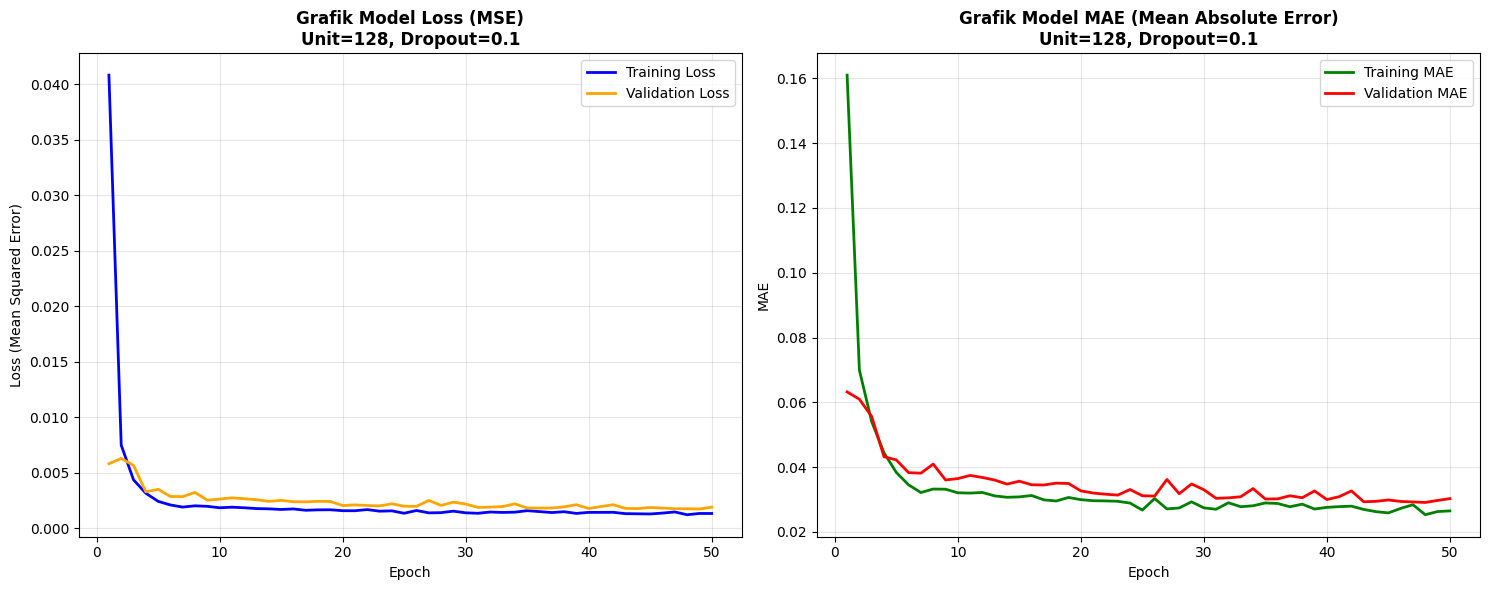

✅ Grafik Loss dan MAE berhasil dibuat dan disimpan.


In [ ]:
import matplotlib.pyplot as plt

# Pastikan best_history tersedia dari proses training sebelumnya
if best_history is None:
    print("⚠️ Harap jalankan proses Grid Search (Langkah 3) terlebih dahulu!")
else:
    # Ambil data history
    hist = best_history.history
    loss_train = hist['loss']
    loss_val = hist['val_loss']
    mae_train = hist['mae']
    mae_val = hist['val_mae']

    epochs_range = range(1, len(loss_train) + 1)

    # Buat Canvas Gambar (2 Kolom: Kiri Loss, Kanan MAE)
    plt.figure(figsize=(15, 6))

    # --- GRAFIK 1: LOSS (MSE) ---
    plt.subplot(1, 2, 1) # (Baris 1, Kolom 2, Gambar ke-1)
    plt.plot(epochs_range, loss_train, label='Training Loss', color='blue', linewidth=2)
    plt.plot(epochs_range, loss_val, label='Validation Loss', color='orange', linewidth=2)
    plt.title(f"Grafik Model Loss (MSE)\nUnit={best_params['Unit']}, Dropout={best_params['Drop']}", fontsize=12, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (Mean Squared Error)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # --- GRAFIK 2: MAE ---
    plt.subplot(1, 2, 2) # (Baris 1, Kolom 2, Gambar ke-2)
    plt.plot(epochs_range, mae_train, label='Training MAE', color='green', linewidth=2)
    plt.plot(epochs_range, mae_val, label='Validation MAE', color='red', linewidth=2)
    plt.title(f"Grafik Model MAE (Mean Absolute Error)\nUnit={best_params['Unit']}, Dropout={best_params['Drop']}", fontsize=12, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Simpan dan Tampilkan
    plt.tight_layout()
    plt.savefig('Grafik_Evaluasi_Lengkap_Loss_MAE.png')
    plt.show()

    print("✅ Grafik Loss dan MAE berhasil dibuat dan disimpan.")

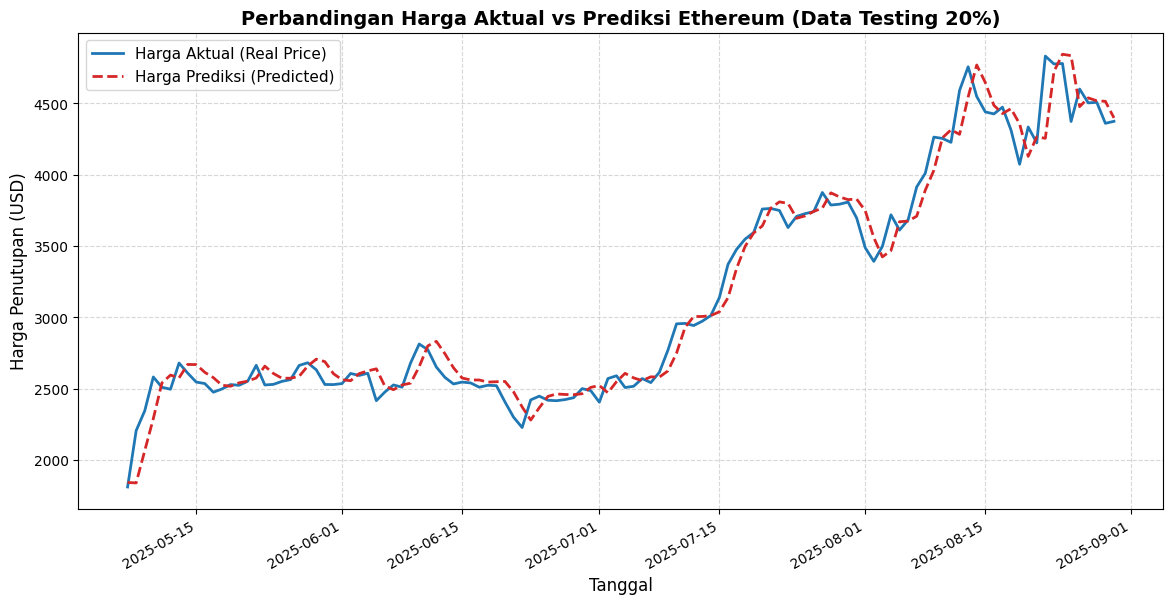

✅ Grafik Prediksi dalam satuan USD berhasil dibuat.


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# --- PERSIAPAN DATA VISUALISASI (HARGA ASLI) ---

# 1. Pastikan data testing dan prediksi tersedia
if best_y_pred is None:
    print("⚠️ Harap jalankan proses Grid Search terlebih dahulu!")
else:
    # 2. Lakukan INVERSE TRANSFORM (PENTING!)
    # Mengembalikan data 0-1 menjadi harga USD asli
    y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1))
    y_pred_real = scaler.inverse_transform(best_y_pred.reshape(-1, 1))

    # 3. Siapkan Tanggal (Sumbu X)
    total_samples = len(X)
    train_size = int(total_samples * 0.8)

    test_start_index = time_step + train_size
    test_dates = df['Date'].iloc[test_start_index:].reset_index(drop=True)

    # Potong panjang array agar sama persis
    min_len = min(len(test_dates), len(y_test_real))
    test_dates = test_dates[:min_len]
    y_test_plot = y_test_real[:min_len]
    y_pred_plot = y_pred_real[:min_len]

    # --- MEMBUAT GRAFIK PREDIKSI VS AKTUAL (HARGA ASLI) ---
    plt.figure(figsize=(14, 7))

    # Plot Data Aktual (Biru)
    plt.plot(test_dates, y_test_plot, label='Harga Aktual (Real Price)', color='#1f77b4', linewidth=2)

    # Plot Data Prediksi (Merah Putus-putus)
    plt.plot(test_dates, y_pred_plot, label='Harga Prediksi (Predicted)', color='#d62728', linestyle='--', linewidth=2)

    # --- FORMATING GRAFIK ---
    plt.title(f"Perbandingan Harga Aktual vs Prediksi Ethereum (Data Testing 20%)",
              fontsize=14, fontweight='bold')
    plt.xlabel("Tanggal", fontsize=12)
    plt.ylabel("Harga Penutupan (USD)", fontsize=12) # Label sumbu Y berubah jadi USD

    plt.legend(loc='upper left', fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.5)

    # Format tanggal di sumbu X agar rapi
    plt.gcf().autofmt_xdate()

    # Simpan Gambar
    plt.savefig('Gambar_4_Hasil_Prediksi_Ethereum_USD.png', dpi=300)
    plt.show()

    print("✅ Grafik Prediksi dalam satuan USD berhasil dibuat.")

In [ ]:
import joblib

# ===============================
# 5. Simpan Model & Scaler
# ===============================

# Simpan scaler
joblib.dump(scaler, "scaler_gru.pkl")
print("📁 Saved scaler as scaler_gru.pkl")

# Simpan model GRU terbaik
best_model.save("gru_model.h5")
print("📁 Saved GRU model as gru_model.h5")


📁 Saved scaler as scaler_gru.pkl
📁 Saved GRU model as gru_model.h5
